<a href="https://colab.research.google.com/github/RamirezTovarDianaGuadalupe/ProcesosEstocasticos/blob/main/Rata_Laberinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\Huge \color{#C5A3A3}{\text{ Rata en el laberinto}}$$

Una rata en un laberinto se mueve aleatoriamente. Si hay k formas de abandonar un laberinto, elije una salida con probabilidad 1/k. ¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

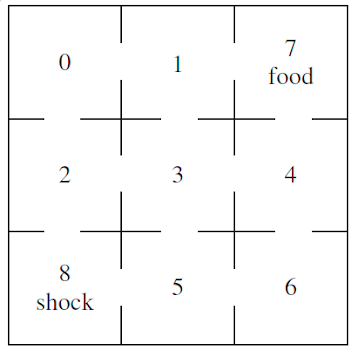

Se importa la librería NumPy, que nos permite trabajar con matrices y realizar cálculos matemáticos de forma rápida.

In [1]:
import numpy as np

Se define la Matriz de Transición ($P$). Cada fila representa una habitación del laberinto y los números indican probabilidad de que la rata se mueva de una habitación a otra.

Por ejemplo, si en una habitación hay dos salidas, la matriz marca $1/2$ (50%) de probabilidad para cada una, los estados 7 (la comida) y 8 (shock), son los puntos donde el juego termina.

In [2]:
# Matriz de transición
P = np.array([
    [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],    # 0
    [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],  # 1
    [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],  # 2
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0], # 3
    [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],  # 4
    [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],  # 5
    [0, 0, 0, 0, 1/2, 1/2, 0, 0, 0],    # 6
    [0, 0, 0, 0, 0, 0, 0, 1, 0],        # 7 (food)
    [0, 0, 0, 0, 0, 0, 0, 0, 1]         # 8 (shock)
])

$$\Large \color{#C5A3A3}{\text{1. Simulación de Monte Carlo}}$$

Para resolver el problema del laberinto, se implemento una simulación de Monte Carlo. La idea es "soltar" a la rata muchas veces en el punto inicial y observar cuántas veces logra llegar a la comida antes del shock.

Se crea la fución que se encarga de mover a la rata paso a paso por el laberinto. Se utiliza un ciclo que no se detiene hasta que la rata llega a la comida o al shock. En cada paso se usa np.random.choice para que la rata elija una salida al azar, respetando siempre las probabilidades de la matriz.

In [3]:

def simular_rata(inicio, matriz):
    estado_actual = inicio
    # La rata se mueve hasta llegar a un estado absorbente (7 u 8)
    while estado_actual < 7:
        # Elige el siguiente estado basado en las probabilidades de la fila
        opciones = np.arange(9)
        probabilidades = matriz[estado_actual]
        estado_actual = np.random.choice(opciones, p=probabilidades)
    return estado_actual

Se programa el experimento para repetirse 10,000 veces. Se utiliza un contador de "éxitos" que empieza en cero y solo aumenta cuando la rata logra terminar en el estado 7 (comida).

In [4]:
# Realiza la simulación 10,000 veces
intentos = 10000
exitos = 0
estado_inicial = 0

for _ in range(intentos):
    resultado = simular_rata(estado_inicial, P)
    if resultado == 7: # Si llegó a la comida
        exitos += 1

Para la probabilidad estimada se divide el número de éxitos entre el total de intentos realizados.

Esta probabilidad nos dice qué tan frecuente es que la rata gane el juego empezando desde el estado inicial.

In [5]:
# Resultado estimado
prob_estimada = exitos / intentos

print(f"{intentos} simulaciones:")
print(f"Veces que llego a la comida: {exitos}")
print(f"Probabilidad estimada empezando en {estado_inicial}: {prob_estimada:.4f}")

10000 simulaciones:
Veces que llego a la comida: 5084
Probabilidad estimada empezando en 0: 0.5084


El resultado se aproxima al 50%, esto nos confirma que el laberinto es equilibrado para ambos destinos.

$$\Large \color{#C5A3A3}{\text{2. Analíticamente}}$$

Este método utiliza el álgebra lineal para obtener el valor exacto de la probabilidad, resolviendo resuelve el sistema matemático que define al laberinto.

En esta parte, se divide la matriz de transición original:

*   La matriz Q, que contiene los estados transitorios del 0 al 6, (la rata puede entrar y salir de ellos varias veces) .
*   La matriz R, que marca las salidas directas hacia la comida estado 7.

Esto se hace para poder aplicar las fórmulas de las cadenas de Markov absorbentes de forma aislada.

In [6]:
# Estados transitorios
transitorios = [0,1,2,3,4,5,6]

# Submatrices
Q = P[np.ix_(transitorios, transitorios)]
R = P[np.ix_(transitorios, [7])]  # Probabilidad de ir a comida

Aquí se resuelve la ecuación $$(I - Q)x = R$$
Se genera una matriz identidad ($I$) y se utiliza la función np.linalg.solve para encontrar el valor de $x$.

Este paso equivale matemáticamente a sumar todas las rutas posibles que la rata podría tomar hasta sllegar al estado final.

In [7]:
# Resolver sistema (I-Q)p = R
I = np.eye(len(Q))
p = np.linalg.solve(I - Q, R)

Finalmente, se muestran las probabilidades calculadas para cada estado transitorio.

In [8]:
# Resultados
print("Probabilidad de llegar primero a comida desde cada estado:")
for estado, prob in zip(transitorios, p):
    print(f"Estado {estado}: {prob[0]:.4f}")

print("\nProbabilidad empezando en 0:", p[0][0])

Probabilidad de llegar primero a comida desde cada estado:
Estado 0: 0.5000
Estado 1: 0.6667
Estado 2: 0.3333
Estado 3: 0.5000
Estado 4: 0.6667
Estado 5: 0.3333
Estado 6: 0.5000

Probabilidad empezando en 0: 0.49999999999999994


 Los resultados de los estados 1 y 4 ($2/3$) contra a los estados 2 y 5 ($1/3$) muestran que la probabilidad de éxito aumenta conforme la rata se acerca a la comida.

$$\Large \color{#C5A3A3}{\text{3. Conclusiones}}$$

Los resultados obtenidos en ambos métodos coinciden.
*   Analítico: 0.4999
*   Monte Carlo: 0.5084

Esta mínima diferencia nos dice que la rata tiene las mismas oportunidades de ganar que de perder.